SPRINT 2 DATA PREPARATION AND EXPLORATION 

In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

In [6]:
DATA_PATH = '/Users/diyapatel/Desktop/Crime_Data_from_2020_to_Present (3).csv'



In [7]:
#LOAD DATA
df = pd.read_csv(DATA_PATH, low_memory=False)
print("Raw shape:", df.shape)

Raw shape: (1004991, 28)


In [8]:
# DROP COLUMNS 
drop_cols = [
    "DR_NO", "Date Rptd", "Rpt Dist No",
    "Status", "Status Desc", "Cross Street",
    "Mocodes", "Crm Cd 1", "Crm Cd 2", "Crm Cd 3", "Crm Cd 4"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

In [10]:
#VICTIM FIELDS CLEANING

df["Vict Age"] = pd.to_numeric(df.get("Vict Age"), errors="coerce")
df.loc[(df["Vict Age"] <= 0) | (df["Vict Age"] > 120), "Vict Age"] = np.nan

age_bins   = [0, 17, 30, 50, 120]
age_labels = ["<18", "18-30", "31-50", "51+"]
df["Vict Age Group"] = pd.cut(df["Vict Age"], bins=age_bins, labels=age_labels, right=True)
df["Vict Age Group"] = df["Vict Age Group"].astype("object").fillna("Unknown")

# Sex: fill missing with "Unknown" (avoids bias from distributional imputation; preserves rows)
if "Vict Sex" in df.columns:
    df["Vict Sex"] = df["Vict Sex"].astype("string").str.strip()
    df["Vict Sex"] = df["Vict Sex"].replace({np.nan: "Unknown", "": "Unknown", "-": "Unknown"})
else:
    df["Vict Sex"] = "Unknown"

# Descent: fill missing with "Unknown"
if "Vict Descent" in df.columns:
    df["Vict Descent"] = df["Vict Descent"].astype("string").str.strip().fillna("Unknown").replace({"": "Unknown"})
else:
    df["Vict Descent"] = "Unknown"


In [11]:
#  Focus on Theft + Break-in/Burglary

desc_col = "Crm Cd Desc"
df[desc_col] = df[desc_col].astype("string")

# wide net for property-theft/burglary terms
mask_property = df[desc_col].str.contains(
    r"THEFT|LARCENY|SHOPLIFT|BURGLAR|BREAK|B&E|B & E|B AND E|RESIDENTIAL BURGLARY|COMMERCIAL BURGLARY",
    case=False, na=False
)

df_prop = df[mask_property].copy()

def map_crime_group(s: str):
    if not isinstance(s, str):
        return np.nan
    u = s.upper()
    # Break-in / Burglary group
    if ("BURGLAR" in u) or ("BREAK" in u) or ("B&E" in u) or ("B & E" in u) or ("B AND E" in u):
        return "Break-in/Burglary"
    # Theft group (keep broad, including larceny/shoplift)
    if ("THEFT" in u) or ("LARCENY" in u) or ("SHOPLIFT" in u):
        return "Theft"
    # anything else in mask
    return "Other Property"

df_prop["crime_group"] = df_prop[desc_col].apply(map_crime_group)

# two groups we care about
df_prop = df_prop[df_prop["crime_group"].isin(["Theft", "Break-in/Burglary"])]

# Binary label 1 = Break-in/Burglary, 0 = Theft
df_prop["crime_binary"] = (df_prop["crime_group"] == "Break-in/Burglary").astype(int)

Select useful columns

In [12]:
columns_to_keep = [
    "crime_group", "crime_binary",
    "Crm Cd", "Crm Cd Desc",
    "Vict Age", "Vict Age Group", "Vict Sex", "Vict Descent",
    "AREA", "AREA NAME",       
    "Premis Cd", "Premis Desc", 
    "LAT", "LON",               
    "DATE OCC", "Hour", "Month", "DayOfWeek"
]

# keep only columns that actually exist
columns_to_keep = [c for c in columns_to_keep if c in df_prop.columns]
df_clean = df_prop[columns_to_keep].copy()

print("Final shape:", df_clean.shape)

Final shape: (411206, 15)


In [13]:
# Save Cleaned Dataset

df_clean.to_csv("cleaned_property_crimes.csv", index=False)
print("Saved cleaned dataset: cleaned_property_crimes.csv")


Saved cleaned dataset: cleaned_property_crimes.csv


EXPLORATORY DATA ANALYSIS (EDA)

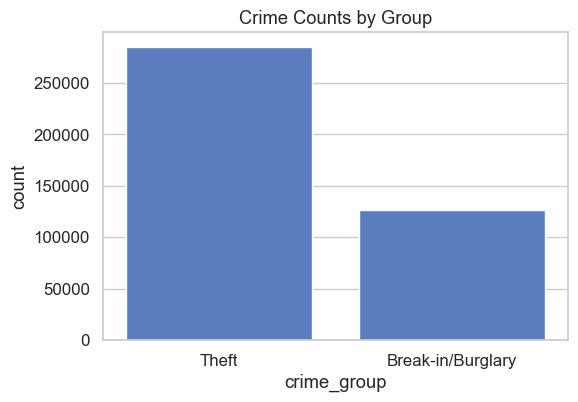

In [14]:
# Crime group counts
plt.figure(figsize=(6,4))
sns.countplot(x="crime_group", data=df_clean, order=df_clean["crime_group"].value_counts().index)
plt.title("Crime Counts by Group")
plt.show()

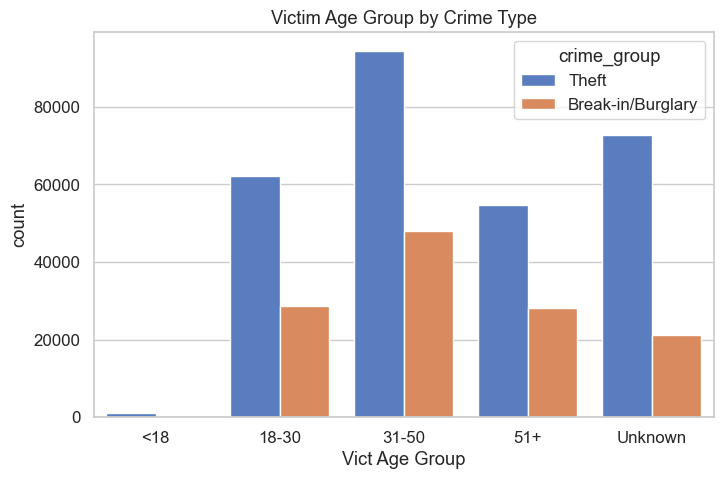

In [15]:
# Victim age distribution by crime group 
plt.figure(figsize=(8,5)) 
sns.countplot(x="Vict Age Group", hue="crime_group", data=df_clean, order=["<18","18-30","31-50","51+","Unknown"]) 
plt.title("Victim Age Group by Crime Type") 
plt.show()

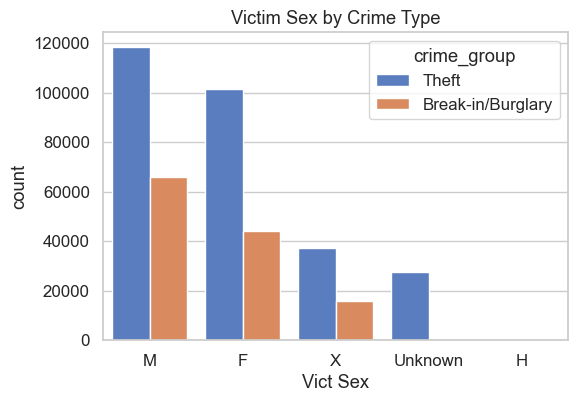

In [17]:
# Victim sex by crime group
plt.figure(figsize=(6,4)) 
sns.countplot(x="Vict Sex", hue="crime_group", data=df_clean) 
plt.title("Victim Sex by Crime Type")
plt.show()

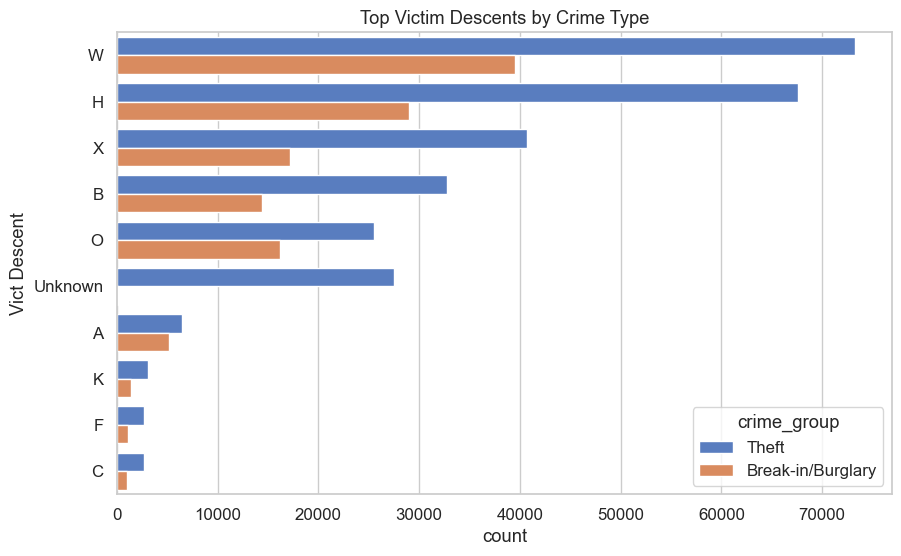

In [19]:
# Victim descent by crime group (top 10 descents) 
top_descent = df_clean["Vict Descent"].value_counts().nlargest(10).index 
plt.figure(figsize=(10,6)) 
sns.countplot(y="Vict Descent", hue="crime_group", data=df_clean[df_clean["Vict Descent"].isin(top_descent)], order=top_descent) 
plt.title("Top Victim Descents by Crime Type") 
plt.show()

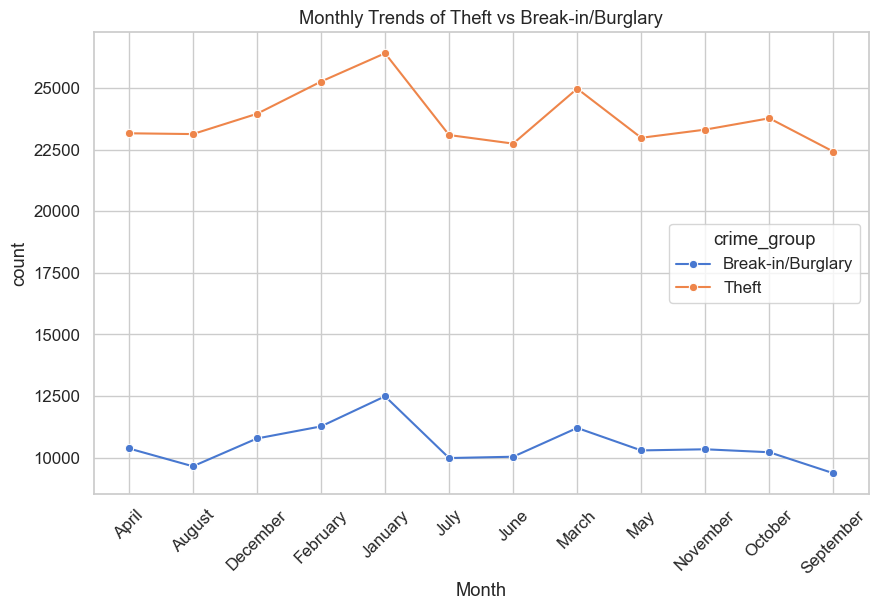

In [28]:
monthly = df_clean.groupby(["Month", "crime_group"]).size().reset_index(name="count")

plt.figure(figsize=(10,6))
sns.lineplot(x="Month", y="count", hue="crime_group", data=monthly, marker="o")
plt.title("Monthly Trends of Theft vs Break-in/Burglary")
plt.xticks(rotation=45)
plt.show()


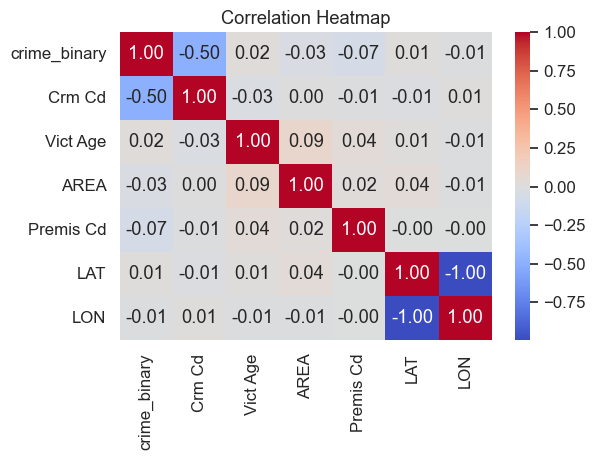

In [29]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(6,4)) 
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f") 
plt.title("Correlation Heatmap")
plt.show()

Notes on Limitations & Bias

In [30]:
print(""" 
      Limitations: 
      1. "Unknown" categories help preserve rows but may introduce bias if missingness is systematic 
      (e.g., some demographics less likely to be recorded).
      2. Invalid ages were set to NaN to avoid skew; grouped into bins for interpretability.
      3. Grouping into Theft vs. Break-in/Burglary improves clarity but loses detail (e.g., shoplifting vs. auto theft).
      4. Data covers only LAPD jurisdictions — may not generalize. 
      5. Class imbalance: Theft dominates, which may affect modeling. """)

 
      Limitations: 
      1. "Unknown" categories help preserve rows but may introduce bias if missingness is systematic 
      (e.g., some demographics less likely to be recorded).
      2. Invalid ages were set to NaN to avoid skew; grouped into bins for interpretability.
      3. Grouping into Theft vs. Break-in/Burglary improves clarity but loses detail (e.g., shoplifting vs. auto theft).
      4. Data covers only LAPD jurisdictions — may not generalize. 
      5. Class imbalance: Theft dominates, which may affect modeling. 


THE WRITE UP FOR SPRINT 2

The dataset used for this project is the LAPD Crime Data (2020 subset). It contains thousands of reported crime incidents across Los Angeles, including variables such as DATE OCC (date of occurrence), AGE, SEX, LOCATION, and crime_group (grouped crime category). The dataset is moderately large, with enough records to reveal meaningful patterns in crime distribution over time, location, and demographic features.

Origin: Public crime dataset (Los Angeles Police Department).
Size: Tens of thousands of rows; multiple categorical and numeric variables.
Features: Includes demographics (age, sex), crime type, location, and date of occurrence.
Limitations: Certain sensitive variables (e.g., detailed crime subcategories) were collapsed into broader groups like Theft, Break-in/Burglary, and Other. This improves interpretability but reduces detail. Some values were missing or invalid, such as blank sex entries or unrealistic ages.



Data Cleaning Log

Several steps were taken to ensure the dataset was usable:

1) Missing values

For categorical fields like SEX, missing entries were filled with "Unknown". This was chosen over dropping rows to avoid losing large portions of data, and over imputation because categories did not have strong distributions that could justify assumptions.
For numeric fields, rows with invalid or impossible values were cleaned (see age handling below).

2) Invalid ages

Negative ages and extreme outliers (e.g., >100 years) were identified as unrealistic and replaced with NaN, then handled during analysis. This avoids misleading trends caused by faulty entries.


3) Date Formatting 
The DATE OCC column was confirmed as proper datetime format, and a Month column was created to allow analysis of seasonal and monthly crime trends.

These steps were logged to maintain transparency in the data pipeline.

EXPLORATORY DATA ANALYSIS 

The cleaned dataset was explored using descriptive statistics and visualizations. Key findings include:

1) Age Distributions by Crime Type

Different crime groups showed different age patterns. For example, theft-related crimes tended to cluster in younger demographics compared to burglary incidents.
Visualization of age histograms by crime group revealed where populations at risk differ across crime categories.

2) Sex Distribution

Males were more frequently involved across most crime groups. However, "Unknown" values may hide systematic bias in reporting.

3) Monthly Trends

A line plot of monthly crime counts showed seasonal fluctuations, with theft generally higher in summer months compared to burglary.
This trend suggests environmental or behavioral patterns driving certain crimes.

4) Correlations

Correlation heatmaps and grouped analysis revealed weak but noticeable relationships between demographic variables (age, sex) and crime categories.

Limitations and Bias

While the dataset is rich, it has important limitations:

Grouped crime categories: Collapsing crimes into 3 broad groups (Theft, Break-in/Burglary, Other) improves readability but sacrifices detail. Sub-crime patterns (e.g., shoplifting vs. auto theft) are hidden.

Handling missing values: Filling "Unknown" for missing sex may introduce bias if these values are not randomly distributed. For example, certain neighborhoods or crime types might be more prone to missing demographic data.

Invalid ages: Removing unrealistic ages avoids distortion but also reduces data size. If faulty age data disproportionately affects one group, bias may remain.

External validity: Data reflects Los Angeles in 2020 only. Trends may not generalize to other regions or time periods.